# Multi Linear Regression and Elastic Net Regression
This notebook processes tabular data to predict the number of calories burned during exercise sessions. 
The task is a supervised regression problem evaluated using the Root Mean Squared Logarithmic Error (RMSLE).

We will test two models:
1. Multiple Linear Regression (as a baseline)
2. Elastic Net Regression (to apply L1 and L2 regularization)

In [ ]:
!pip install -r requirements.txt

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.metrics import mean_squared_log_error
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We load the `train.csv` dataset. The total dataset has entries for `id`, `Sex`, `Age`, `Height`, `Weight`, `Duration`, `Heart_Rate`, `Body_Temp`, and `Calories`.

In [36]:
# Load the Data
df = pd.read_csv('train.csv')
df.head()

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0


## 2. Preprocessing
We convert the categorical `Sex` column into numerical values. We then separate our features (`X`) from our target variable (`y`), dropping the `id` field since it provides no predictive value.

In [37]:
# Convert the categorical 'Sex' column to numerical values (0 and 1)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define features (X) and target (y)
X = df.drop(['id', 'Calories'], axis=1)
y = df['Calories']

## 3. Internal Validation Split & Target Transformation
We split the data into 75% training and 25% testing sets. 
Because the evaluation metric is Root Mean Squared Logarithmic Error (RMSLE), we apply a logarithmic transformation (`log1p`) to our target variable `y` before training. This natively optimizes our models for RMSLE and prevents errors with negative predictions.

In [38]:
# Split into 75% training and 25% internal validation to compare models
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.25, random_state=42)

# Apply log1p (log(1 + x)) transformation to the target
y_train_log = np.log1p(y_train)

## 4. Model Training & Prediction on Validation Set
We train both the Multiple Linear Regression and the Elastic Net Regression models on the 75% split.

In [39]:
# Multiple Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train_log)

# Predict and revert the log transformation using expm1 (exp(x) - 1)
lr_preds = np.expm1(lr_model.predict(X_val))

# Elastic Net Regression
en_model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
en_model.fit(X_train, y_train_log)

# Predict and revert the log transformation
en_preds = np.expm1(en_model.predict(X_val))

## 5. Local Evaluation
We calculate the RMSLE for both models on our 25% validation set to determine the winner.

----------------------------------------
Multiple Linear Regression Validation RMSLE: 0.17994
Elastic Net Regression Validation RMSLE:     0.18220
----------------------------------------


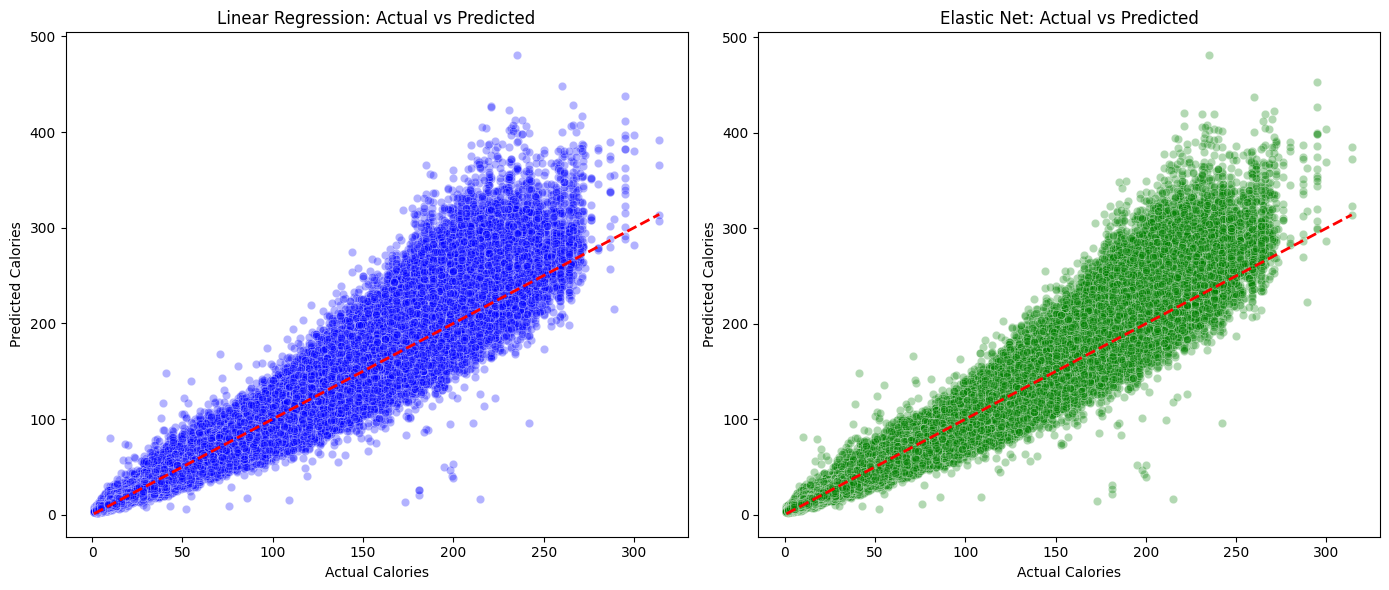

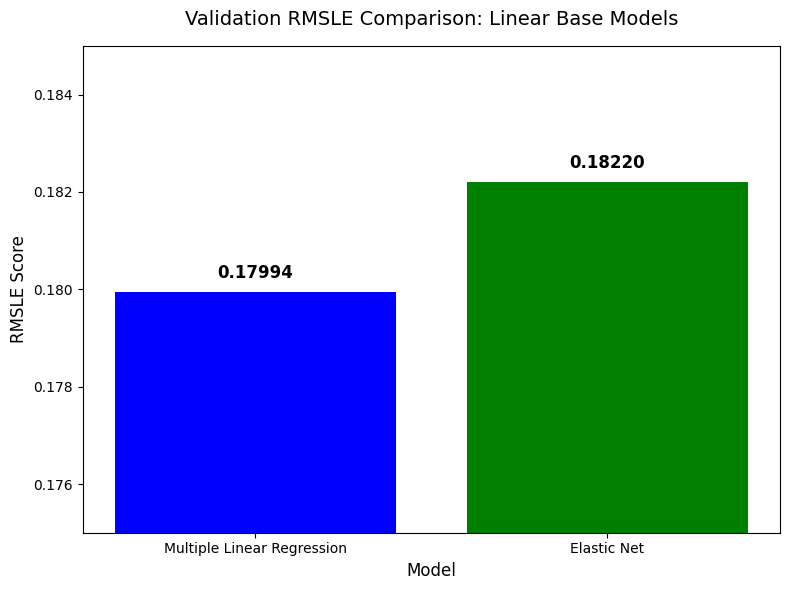

In [ ]:
# Calculate RMSLE by taking the square root of MSLE
lr_rmsle = np.sqrt(mean_squared_log_error(y_val, lr_preds))
en_rmsle = np.sqrt(mean_squared_log_error(y_val, en_preds))

print("-" * 40)
print(f"Multiple Linear Regression Validation RMSLE: {lr_rmsle:.5f}")
print(f"Elastic Net Regression Validation RMSLE:     {en_rmsle:.5f}")
print("-" * 40)

plt.figure(figsize=(14, 6))

# Multiple Linear Regression Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_val, y=lr_preds, alpha=0.3, color='blue')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')

# Elastic Net Plot
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_val, y=en_preds, alpha=0.3, color='green')
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
plt.title('Elastic Net: Actual vs Predicted')
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')

plt.tight_layout()
plt.savefig('regression_scatter_plots.png', dpi=300, bbox_inches='tight')
plt.show()

# RMSLE comparison graph
models = ['Multiple Linear Regression', 'Elastic Net']
rmsle_scores = [0.17994, 0.18220]

plt.figure(figsize=(8, 6))
bars = plt.bar(models, rmsle_scores, color=['blue', 'green'])
plt.title('Validation RMSLE Comparison: Linear Base Models', fontsize=14, pad=15)
plt.ylabel('RMSLE Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0.175, 0.185)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.0002, f"{yval:.5f}", ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('linear_models_rmsle_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Retrain Best Model on ALL Training Data
Now that we know which model works best, we retrain it on the entire `train.csv` dataset so it can learn from as much data as possible before we generate our final Kaggle predictions.

In [41]:
# Choose the better model
best_model = LinearRegression() if lr_rmsle < en_rmsle else ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)

# Apply log transform to the full training target
y_log_full = np.log1p(y)

# Retrain on train.csv
best_model.fit(X, y_log_full)
print("Best model successfully retrained on the full dataset!")

Best model successfully retrained on the full dataset!


## 7. Generate Final Submission from Kaggle's `test.csv`
We now load Kaggle's separate `test.csv` file, preprocess it exactly the same way, predict the missing `Calories`, and save it.

In [42]:
def generate_kaggle_submission(model, test_file_path='test.csv', output_file='submission.csv'):
    try:
        test_df = pd.read_csv(test_file_path)
        
        # Preprocess the Kaggle test data
        test_df['Sex'] = test_df['Sex'].map({'male': 0, 'female': 1})
        X_competition = test_df.drop(['id'], axis=1)
        
        # Predict using the fully trained best model and revert log transformation
        final_preds = np.expm1(model.predict(X_competition))
        
        # Format for Kaggle submission
        submission = pd.DataFrame({
            'id': test_df['id'],
            'Calories': final_preds
        })
        
        submission.to_csv(output_file, index=False)
        print(f"Successfully created {output_file} from {test_file_path}!")
        print(submission.head())
        
    except FileNotFoundError:
        print(f"Note: '{test_file_path}' not found. Please ensure Kaggle's test dataset is downloaded and in the same directory.")

# Generate the final CSV
generate_kaggle_submission(best_model)


Successfully created submission.csv from test.csv!
       id    Calories
0  750000   33.603486
1  750001   98.562174
2  750002   91.257655
3  750003  139.606065
4  750004   79.037489
